In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#LOAD DATA
train_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    r"C:\Users\JINESHA GANDHI\Downloads\PetImages\PetImages",
    target_size=(64,64),
    batch_size=32,
    class_mode=None,
    shuffle=True
)

Found 24998 images belonging to 2 classes.


In [2]:
#GENERATOR
def build_generator():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(100,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(64*64*3, activation='tanh'),
        layers.Reshape((64,64,3))
    ])
    return model

#DISCRIMINATOR
def build_discriminator():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(64,64,3)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    return model

generator = build_generator()
discriminator = build_discriminator()

In [3]:
#GAN
discriminator.trainable = False

gan_input = tf.keras.Input(shape=(100,))
fake_img = generator(gan_input)
gan_output = discriminator(fake_img)

gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

#TRAIN
epochs = 200
d_losses, g_losses = [], []

for epoch in range(epochs):

    real_imgs = next(train_data)
    n = real_imgs.shape[0]

    noise = np.random.normal(0,1,(n,100))
    fake_imgs = generator.predict(noise, verbose=0)

    discriminator.trainable = True
    d_loss_real = discriminator.train_on_batch(real_imgs, np.ones((n,1)))
    d_loss_fake = discriminator.train_on_batch(fake_imgs, np.zeros((n,1)))
    d_loss = 0.5 * (d_loss_real + d_loss_fake)

    discriminator.trainable = False
    g_loss = gan.train_on_batch(noise, np.ones((n,1)))

    d_losses.append(d_loss)
    g_losses.append(g_loss)

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss:.4f} | G Loss: {g_loss:.4f}")

Epoch 0 | D Loss: 0.6256 | G Loss: 2.0838
Epoch 50 | D Loss: 1.2468 | G Loss: 2.5814
Epoch 100 | D Loss: 1.3062 | G Loss: 5.3867
Epoch 150 | D Loss: 0.9197 | G Loss: 8.1788


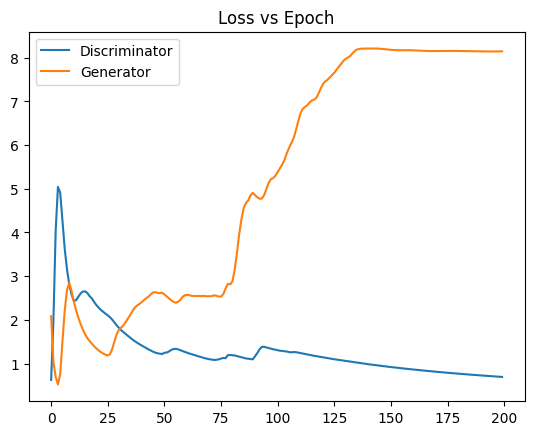

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


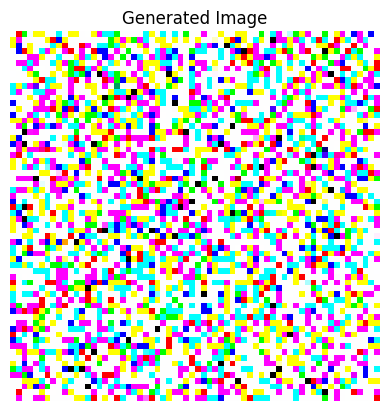

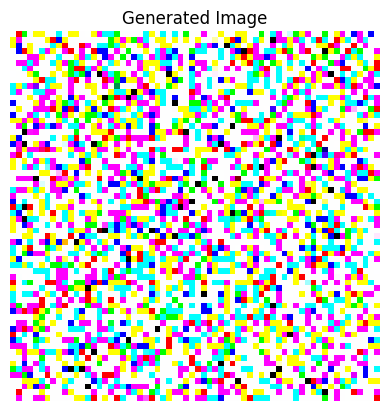

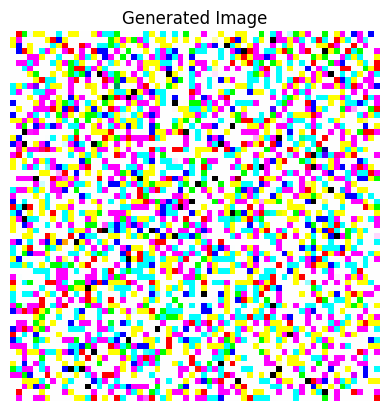

In [4]:
#LOSS GRAPH  
plt.plot(d_losses, label='Discriminator')
plt.plot(g_losses, label='Generator')
plt.title("Loss vs Epoch")
plt.legend()
plt.show()

#GENERATE IMAGES  
noise = np.random.normal(0,1,(3,100))
generated = generator.predict(noise)

generated = (generated + 1) / 2.0  # scale fix

for i in range(3):
    plt.imshow(generated[i])
    plt.title("Generated Image")
    plt.axis('off')
    plt.show()